In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import preliz as pz
import scipy.stats as stats
from cycler import cycler

In [2]:
az.style.use("arviz-darkgrid")
np.random.seed(314)

default_cycler = cycler(color=["#000000", "#6a6a6a", "#bebebe", "#2a2eec"])
plt.rc("axes", prop_cycle=default_cycler)
plt.rc("figure", dpi=100)

# Thinking Probabilistically

## Discrete random variables and their distributions

### Code 1.2

In [3]:
betabiom = pz.BetaBinomial(alpha=2, beta=5, n=5)
# betabiom.plot_interactive()

### Code 1.3

In [4]:
pz.BetaBinomial(alpha=10, beta=10, n=6).rvs()

/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


array(4)

In [5]:
pmfs = betabiom.pdf(range(6))
[(i, f"{x:0.3f}") for i, x in enumerate(pmfs)]

[(0, '0.273'),
 (1, '0.303'),
 (2, '0.227'),
 (3, '0.130'),
 (4, '0.054'),
 (5, '0.013')]

### Code 1.4

/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


<Axes: >

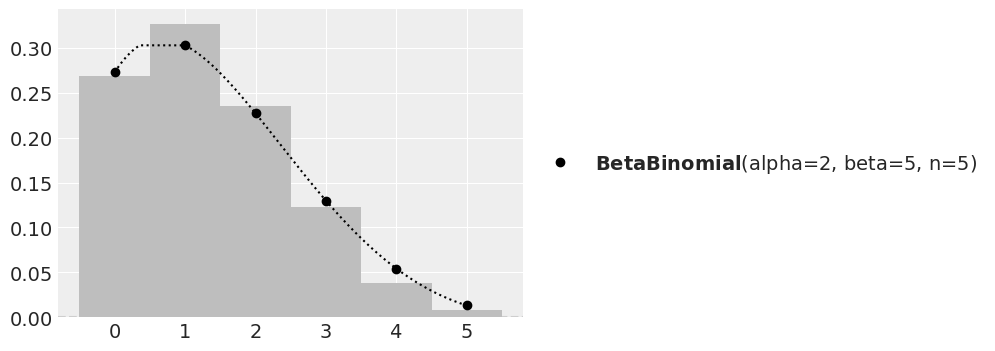

In [6]:
_, ax = plt.subplots(figsize=(6, 4))
ax.hist(
    betabiom.rvs(1000),
    bins=[0, 1, 2, 3, 4, 5, 6],
    density=True,
    align="left",
    color="C2",
)
betabiom.plot_pdf(ax=ax)

### Code 1.5

np.float64(0.4772498680518208)

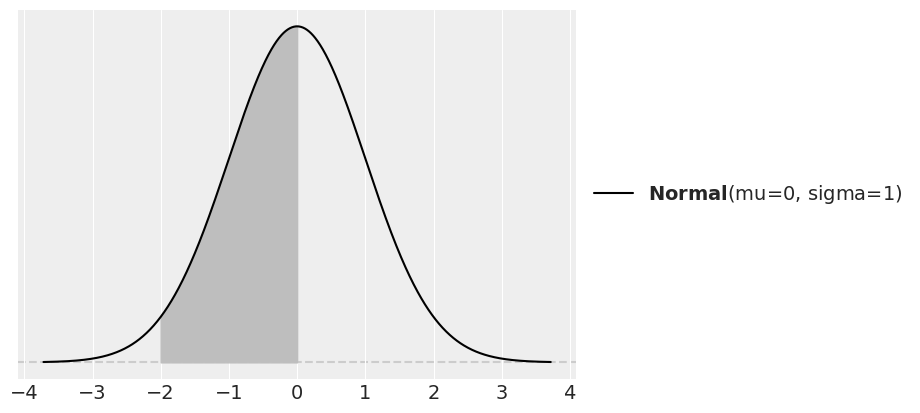

In [7]:
norm = pz.Normal(0, 1)
axn = norm.plot_pdf()
a, b = (-2, 0)
xs = np.linspace(a, b)
axn.fill_between(xs, norm.pdf(xs), color="C2")
norm.cdf(0) - norm.cdf(-2)

## Cumulative distribution function

### Figure 1.7

<Axes: >

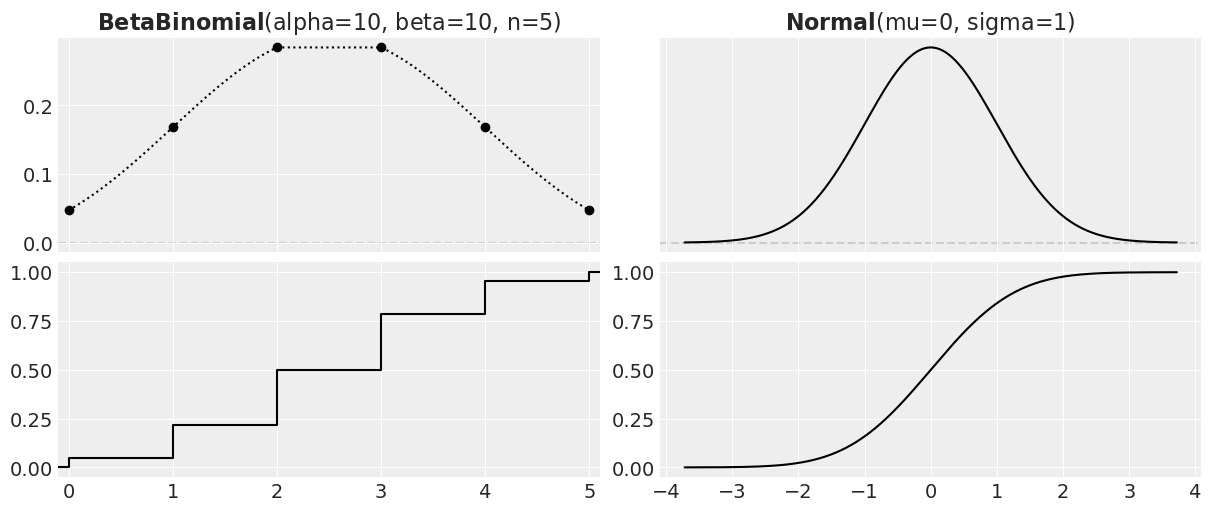

In [8]:
_, axes = plt.subplots(2, 2, figsize=(12, 5), sharex="col")
pz.BetaBinomial(alpha=10, beta=10, n=5).plot_pdf(ax=axes[0, 0], legend="title")
pz.BetaBinomial(alpha=10, beta=10, n=5).plot_cdf(ax=axes[1, 0], legend=None)
pz.Normal(0, 1).plot_pdf(ax=axes[0, 1], legend="title")
pz.Normal(0, 1).plot_cdf(ax=axes[1, 1], legend=None)

## Choosing the prior

### Figure 1.11

/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run XlogY0's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


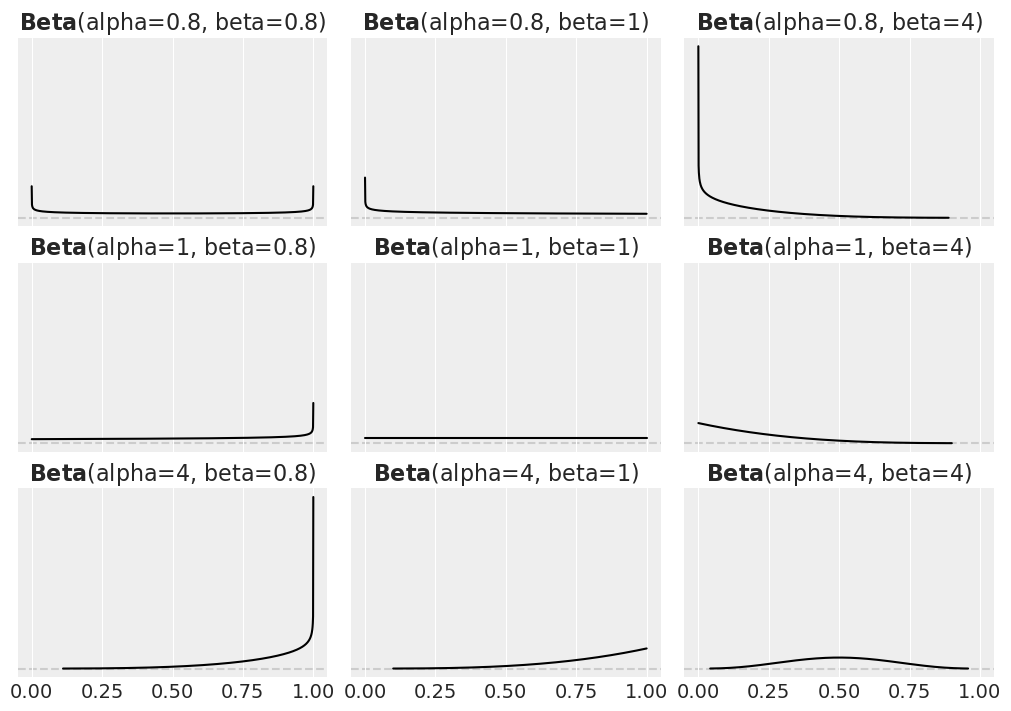

In [9]:
params = [0.8, 1, 4]
_, axes2 = plt.subplots(3, 3, figsize=(10, 7), sharex=True, sharey=True)
for i, α in enumerate(params):
    for j, β in enumerate(params):
        pz.Beta(α, β).plot_pdf(legend="title", ax=axes2[i, j])

### Code 1.6

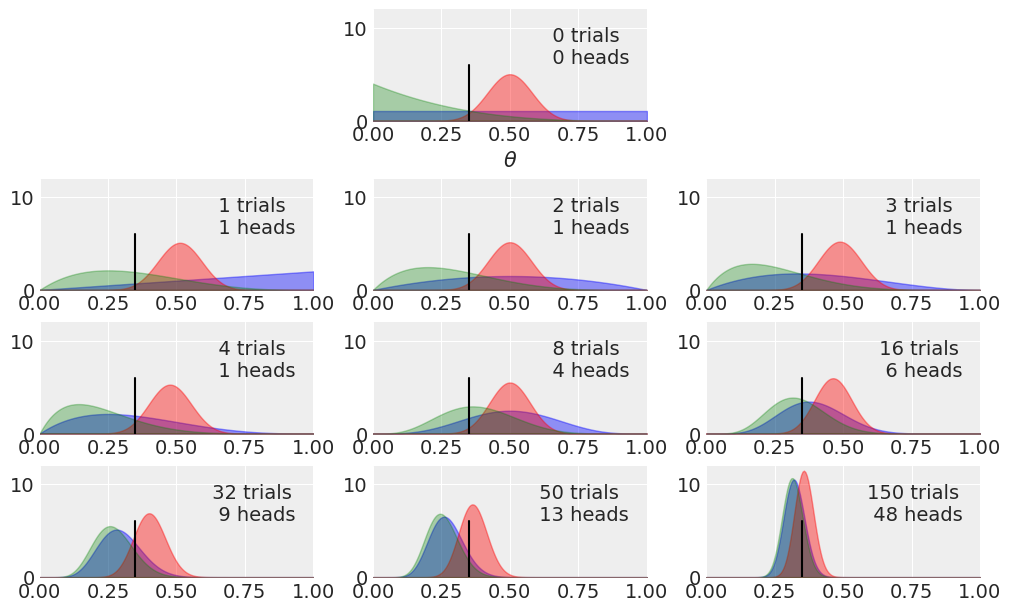

In [10]:
n_trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
data = [0, 1, 1, 1, 1, 4, 6, 9, 13, 48]
θ_real = 0.35
βs = [(1, 1), (20, 20), (1, 4)]
colors = ["blue", "red", "green"]
alphas = [0.4, 0.4, 0.3]
x = np.linspace(0, 1, 200)

_, axes_coin = plt.subplots(4, 3, figsize=(10, 6), constrained_layout=True)
for ind, N in enumerate(n_trials):
    y = data[ind]
    ind = 1 if ind == 0 else ind + 2
    axi = axes_coin.flatten()[ind]
    for (a_prior, b_prior), color, alpha in zip(βs, colors, alphas):
        p_θ_given_y = stats.beta.pdf(x, a_prior + y, b_prior + N - y)
        axi.fill_between(x, 0, p_θ_given_y, color=color, alpha=alpha)
    axi.axvline(θ_real, ymax=0.5, color="k")
    axi.plot(0, 0, label=f"{N:4d} trials\n{y:4d} heads", alpha=0)
    axi.set(xlim=(0, 1), ylim=(0, 12))
    axi.legend(frameon=False)
axes_coin[0, 1].set(xlabel="$θ$")
axes_coin[0, 0].set_visible(False)
axes_coin[0, 2].set_visible(False)

## How to choose priors

### Code 1.7

(Beta(alpha=2.47, beta=3.61), <Axes: >)

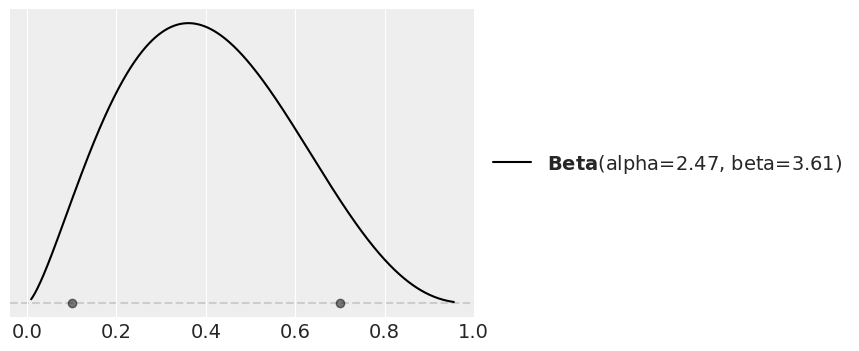

In [11]:
# find the Beta distribution with 90% of the mass between 0.1 and 0.7
dist = pz.Beta()
_, ax2 = plt.subplots(figsize=(6, 4))

pz.maxent(dist, 0.1, 0.7, mass=0.9, ax=ax2)

## Communicating a Bayesian analysis

### Code 1.8

<Axes: title={'center': 'θ'}>

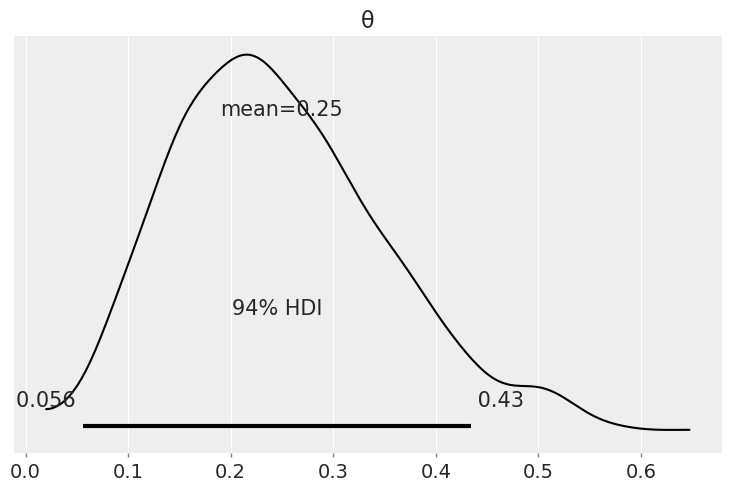

In [12]:
# generate a plot with the mean and HDI of 𝜃
np.random.seed(1)
az.plot_posterior({"θ": pz.Beta(4, 12).rvs(1000)})